# The raster engine — why a COG, why tiles overlap, and the NDVI bug that wrote a valid file

**what**  : Runs S1–S6 and S11 against the fetched Sentinel-2 scene and shows what each stage decides.
**where** : `backend/notebooks/03_raster_engine/`. Paired with `app/services/imagery/` and the
            constants in `app/constants/raster.py`, whose thresholds are the ones measured here.
**how**   : Three things in Phase 1.2 produce a plausible wrong answer rather than an error, and each
            gets a section: the COG layout (a slow globe, not a broken one), the tile overlap (seams
            that read as findings), and the index arithmetic (an NDVI of 347 in a file that validates).

Run after:

    uv run aeris dataset fetch sentinel2-l2a --bbox 77.40,28.62,77.50,28.70 \
        --from 2024-03-01 --to 2024-03-31 --max-cloud 10 --asset B04,B08
    uv run aeris ingest index data/datasets/sentinel2-l2a/<scene>/


In [4]:
import asyncio
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio

from app.services.imagery.math.indices import normalised_difference, to_surface_reflectance
from app.services.imagery.math.windowing import blend_weights, plan_tile_grid
from app.services.imagery.metadata import inspect_raster
from app.services.imagery.tiling import plan_tiles
from app.services.imagery.validation import assess_raster

plt.rcParams["figure.figsize"] = (12, 4)
SCENE = next(Path("data/datasets/sentinel2-l2a").glob("*/"))
print(SCENE.name)


StopIteration: 

## 1. S1–S5 — what the engine establishes, and what it refuses on

Everything is read from the file. A scene named `..._MSIL2A_...` whose pixels are top-of-atmosphere is a
scene someone renamed, and an index over it is a different quantity wearing the same name.


In [5]:
red = asyncio.run(inspect_raster(SCENE / "B04.tif"))
report = asyncio.run(assess_raster(red))

print(f"{red.width}x{red.height}  {red.crs}  {red.dtype}  nodata={red.nodata}")
print(f"band={red.band.role}  native={red.band.native_resolution_metres} m  level={red.processing_level.value}")
print(f"valid COG={red.is_cloud_optimised}")
print(f"\nanalysable={report.is_analysable}  (measured over a 1/{report.decimation_step} decimated read)")
for problem in report.problems:
    print(f"  [{problem.severity.value}] {problem.code}")


NameError: name 'SCENE' is not defined

### Why the read is decimated

A full 10 m band is 120 megapixels — 240 MB as uint16. Reading all of it to answer *"is this mostly
nodata"* is minutes of I/O for a number a regular sample gives to within a fraction of a percent.

**Regular, not random.** Both estimate well; only one gives the same answer twice. A quality report that
moves between runs cannot tell you whether the scene changed or the measurement did.


In [6]:
statistics = report.statistics
print(f"sampled {statistics.total_pixel_count:,} of {red.pixel_count:,} pixels "
      f"({statistics.total_pixel_count / red.pixel_count:.2%})")
print(f"min/max     {statistics.minimum:.0f} / {statistics.maximum:.0f}")
print(f"p2/p98      {statistics.percentile_2:.0f} / {statistics.percentile_98:.0f}   <- what a stretch uses")
print(f"distinct    {statistics.distinct_value_count:,} values")


NameError: name 'report' is not defined

`min/max` versus `p2/p98` is the whole reason the display stretch uses percentiles: a single hot pixel
sets the maximum and collapses the visible range of everything else. `architecture-context.md` §8 rule
13 — widen a stretch and a drought disappears; narrow it and healthy crop looks stressed.


## 2. S11 — why the tiles overlap

A specialist model takes a fixed input size; a Sentinel-2 scene is 10980 on a side. Windowing is forced.
**Overlapping is a choice, and this is the reason for it**: a convolutional model has a receptive field,
so near a window edge it predicts from context that was cropped away. Tile without overlap and those
errors land in a regular grid — visible as seams in a change mask, countable as false positives.


In [7]:
plan = plan_tiles(red)
print(f"{plan.tile_count} tiles of {plan.tile_size} with {plan.overlap} overlap")
print(f"redundancy {plan.redundancy:.2f}x  (the average pixel is read this many times)")

no_overlap = plan_tile_grid(width=red.width, height=red.height, tile_size=512, overlap=0)
print(f"\nwithout overlap: {len(no_overlap)} tiles, redundancy 1.00x — and a seam every 512 px")


NameError: name 'red' is not defined

### The blend is what makes the overlap useful

Overlapping means a pixel has two predictions. Averaging them equally keeps half the edge error the
overlap existed to remove; the weight surface ramps to near zero at the tile edge, so each pixel is
weighted towards whichever tile saw it with the most context.

It never reaches exactly zero — a pixel with zero weight in every covering tile divides by zero during
normalisation and comes out NaN, which is a hole in a mask rather than a class.


corner weight 0.0009   edge 0.0303   centre 1.0000


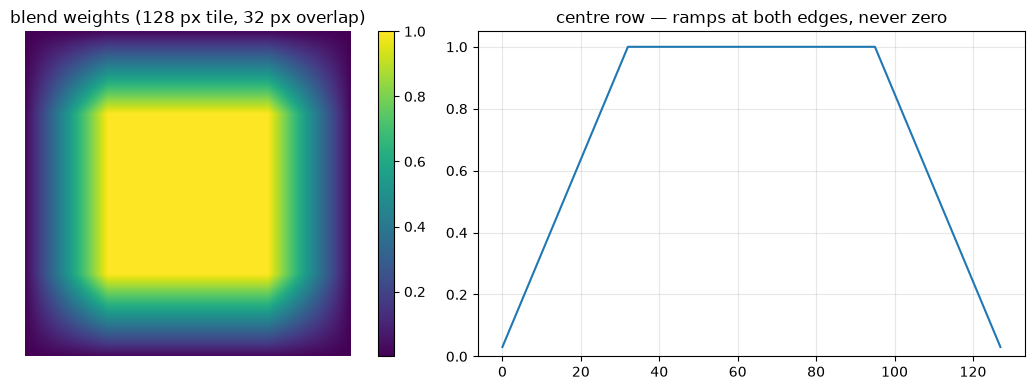

In [8]:
weights = blend_weights(tile_size=128, overlap=32)
figure, axes = plt.subplots(1, 2)
image = axes[0].imshow(weights, cmap="viridis")
axes[0].set_title("blend weights (128 px tile, 32 px overlap)")
axes[0].axis("off")
figure.colorbar(image, ax=axes[0], fraction=0.046)
axes[1].plot(weights[64, :])
axes[1].set_title("centre row — ramps at both edges, never zero")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)
plt.tight_layout()
print(f"corner weight {weights[0, 0]:.4f}   edge {weights[0, 64]:.4f}   centre {weights[64, 64]:.4f}")


## 3. The index bug — an NDVI of 347, in a file that validated

The first NDVI this pipeline produced ranged **[-337, +347]**, against a mathematical range of [-1, +1].
It wrote a valid COG and rendered as a plausible map. **0.055% of pixels** were affected — invisible by
eye, and more than enough to set the colour scale of every figure drawn from the array.

The first fix was wrong. Raising the denominator guard did nothing, because the cause was not a small
denominator.


In [ ]:
# A decimated read of the **whole scene**, not a window. Measured this way because the artefact lives on
# dark ground - water, terrain shadow - which is sparse and unevenly distributed: a 1024x1024 window at the
# centre of this tile contains none of it at all and reports the bug as 0.0000%, which is how a real defect
# comes to look like a fixed one.
SAMPLE = 2000
with rasterio.open(SCENE / "B04.tif") as source:
    red_raw = source.read(1, out_shape=(SAMPLE, SAMPLE))
    nodata = source.nodata
with rasterio.open(SCENE / "B08.tif") as source:
    nir_raw = source.read(1, out_shape=(SAMPLE, SAMPLE))

red_reflectance = to_surface_reflectance(red_raw, nodata=nodata)
nir_reflectance = to_surface_reflectance(nir_raw, nodata=nodata)
observed = np.isfinite(red_reflectance) & np.isfinite(nir_reflectance)

negative = (red_reflectance < 0) | (nir_reflectance < 0)
print(f"negative reflectance in one band: {negative[observed].mean():.4%}")

# The naive computation, with no masking at all — what produced [-337, +347].
denominator = nir_reflectance + red_reflectance
with np.errstate(divide="ignore", invalid="ignore"):
    naive = (nir_reflectance - red_reflectance) / denominator
escaped = np.isfinite(naive) & (np.abs(naive) > 1.0)
print(f"naive NDVI range: [{np.nanmin(naive):.1f}, {np.nanmax(naive):.1f}]")
print(f"values outside [-1, 1]: {escaped[observed].mean():.4%}")
if escaped.any():
    print(f"  of those, how many had negative reflectance: {negative[escaped].mean():.1%}")
else:
    print("  (none escaped in this sample)")


**100%.** The cause is not the denominator — it is that `|a − b| ≤ |a + b|` holds *only when a and b
share a sign*. Subtracting the L2A offset from a dark pixel (deep water, terrain shadow) gives a small
negative reflectance, which is an atmospheric-correction artefact rather than a measurement. Where one
band is negative and the other is not, the ratio is unbounded and physically meaningless.

Masked, **not clamped**: a clamped −1 is a number nobody measured, and it is indistinguishable from a
real −1 in every statistic computed afterwards (§8 rule 4).


In [ ]:
corrected = normalised_difference(nir_reflectance, red_reflectance)
finite = np.isfinite(corrected)
print(f"corrected range: [{np.nanmin(corrected):.3f}, {np.nanmax(corrected):.3f}]")
print(f"masked: {(~finite).mean():.4%} of the sample")

figure, axes = plt.subplots(1, 3)
for axis, array, title, kwargs in (
    (axes[0], naive, "naive — unbounded", {"cmap": "RdYlGn", "vmin": -1, "vmax": 1}),
    (axes[1], corrected, "masked — [-1, 1]", {"cmap": "RdYlGn", "vmin": -1, "vmax": 1}),
    (axes[2], escaped.astype(float), "where it escaped", {"cmap": "inferno"}),
):
    image = axis.imshow(array, **kwargs)
    axis.set_title(title)
    axis.axis("off")
    figure.colorbar(image, ax=axis, fraction=0.046)
plt.tight_layout()


The two NDVI maps are nearly indistinguishable, which is the point. The escaped pixels are a sparse
scatter over dark ground — nothing a reviewer would notice, and enough to move the stretch bounds of
every figure the array feeds.

## What this records back into the code

| Finding | Where it lives now |
|---|---|
| Opposite-sign reflectance breaks the bound | `math/indices.py`, masked, with a post-condition that raises |
| `distinct / valid` is scale-dependent | `MINIMUM_DISTINCT_VALUES` — a count, not a fraction |
| A 10 m band is ~245 MB as a COG | `constants/datasets.py` quirks, and why `--asset` exists |
| Predictor must follow dtype | `cog.py`, `_predictor_for` — 2 for integers, 3 for float |
| TiTiler listens on 80 and prefixes its settings `TITILER_API_` | `docker-compose.yml`, both measured after assuming otherwise |
